# Quick K=2 Gaussian Pilot

This notebook is a deliberately cheap sanity check. It applies rolling standardization to the crypto return panel, switches the HMM to `K = 2` with Gaussian emissions, and runs a tiny full-gradient Langevin pilot so we can see whether the one-state collapse improves before spending real compute.

## What this notebook is trying to answer

- Does preprocessing the returns for local volatility help regime separation?
- Does a simpler `K = 2` model behave better than the original `K = 3` Student-t model?
- Do Gaussian emissions avoid letting heavy tails absorb all the stress periods?
- Can we get a fast directional answer in about a minute rather than another overnight run?

In [1]:
import json
from pathlib import Path

import arviz as az
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
from IPython.display import display
from jax.flatten_util import ravel_pytree

## Paths and local table I/O helpers

This keeps the notebook local-Jupyter-safe and works whether the saved Stage 1 tables are in parquet or pickle format.

In [3]:
PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / 'crypto_stage1_processed'
OUT_DIR = DATA_DIR / 'quick_checks' / 'k2_gaussian_rollstd'
OUT_DIR.mkdir(parents=True, exist_ok=True)


def resolve_table_path(base_path) -> Path:
    base = Path(base_path)
    candidates = [base] if base.suffix in {'.parquet', '.pkl'} else [base.with_suffix('.parquet'), base.with_suffix('.pkl')]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'No saved table found for {base}')


def read_table(base_path) -> pd.DataFrame:
    path = resolve_table_path(base_path)
    if path.suffix == '.parquet':
        return pd.read_parquet(path)
    if path.suffix == '.pkl':
        return pd.read_pickle(path)
    raise ValueError(f'Unsupported table suffix: {path.suffix}')

## Preprocess the returns with rolling standardization

The original project fit the HMM on raw daily log returns. Here we standardize each asset by a rolling mean and rolling standard deviation so the emissions see a more locally stationary series.

In [5]:
returns = read_table(DATA_DIR / 'returns_daily').copy()
RET_COLS = [c for c in returns.columns if c.endswith('_ret')]

ROLL_WINDOW = 30
roll_mean = returns[RET_COLS].rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).mean()
roll_std = returns[RET_COLS].rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).std()

returns_rollstd = returns[['date']].copy()
returns_rollstd[RET_COLS] = (returns[RET_COLS] - roll_mean) / roll_std
returns_rollstd = returns_rollstd.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

R_np = returns_rollstd[RET_COLS].to_numpy(dtype=np.float32)
dates = pd.to_datetime(returns_rollstd['date']).reset_index(drop=True)
R = jnp.array(R_np)
T, d = R_np.shape

print('rolling-standardized sample shape:', R_np.shape)
display(returns_rollstd.head())
display(returns_rollstd[RET_COLS].describe().T[['mean', 'std', 'min', 'max']])

rolling-standardized sample shape: (1994, 5)


,date,BTC_ret,ETH_ret,SOL_ret,BNB_ret,AVAX_ret
0,2020-10-22 00:00:00+00:00,0.399121,1.708647,0.830119,0.641052,0.923310
1,2020-10-23 00:00:00+00:00,-0.623360,-0.728717,0.217990,-0.304456,-0.335798
2,2020-10-24 00:00:00+00:00,0.473779,0.078759,-0.118305,-0.216738,-0.254969
3,2020-10-25 00:00:00+00:00,-0.781368,-0.852888,-0.825982,-0.796929,-0.070919
4,2020-10-26 00:00:00+00:00,-0.285961,-1.499867,-0.778629,0.836527,0.052243


,mean,std,min,max
BTC_ret,-0.007982,0.993418,-4.390128,3.897169
ETH_ret,-0.003047,0.995551,-4.489455,4.156594
SOL_ret,0.003201,0.996334,-4.546129,4.020903
BNB_ret,0.009119,1.000833,-4.563109,3.705710
AVAX_ret,0.011802,0.997795,-4.307515,4.093867


## Quick model settings

We keep the model intentionally small and cheap: two regimes, Gaussian emissions, and weak regularization.

In [7]:
K = 2
SIGMA_MU = 0.25
SIGMA_TRANS = 1.0
SIGMA_CHOL = 1.0
DIAG_FLOOR = 1e-4

MAP_STEPS = 120
MAP_LR = 5e-3
MAP_PRINT_EVERY = 20

N_CHAINS = 2
CHAIN_STEPS = 120
BURN_IN = 40
SAVE_EVERY = 5
ETA = 2e-4
CHAIN_INIT_NOISE = 0.02
MAX_GRAD_NORM = 200.0
TRACE_EVERY = 10

print({
    'K': K,
    'MAP_STEPS': MAP_STEPS,
    'N_CHAINS': N_CHAINS,
    'CHAIN_STEPS': CHAIN_STEPS,
    'BURN_IN': BURN_IN,
    'SAVE_EVERY': SAVE_EVERY,
    'ETA': ETA,
})

{'K': 2, 'MAP_STEPS': 120, 'N_CHAINS': 2, 'CHAIN_STEPS': 120, 'BURN_IN': 40, 'SAVE_EVERY': 5, 'ETA': 0.0002}


## Gaussian HMM building blocks

These cells define the transformed parameters, Gaussian emission log-density, HMM recursions, smoothing, and the MAP objective.

In [9]:
def inv_softplus(x):
    x = np.asarray(x, dtype=np.float32)
    return np.log(np.expm1(np.maximum(x, 1e-6))).astype(np.float32)


def stationary_dist(A: jnp.ndarray, n_iter: int = 200) -> jnp.ndarray:
    def body_fun(_, pi):
        pi = pi @ A
        pi = pi / jnp.sum(pi)
        return pi

    pi0 = jnp.ones((A.shape[0],), dtype=jnp.float32) / A.shape[0]
    return jax.lax.fori_loop(0, n_iter, body_fun, pi0)


def make_cholesky(chol_lower_raw: jnp.ndarray, chol_diag_raw: jnp.ndarray) -> jnp.ndarray:
    strictly_lower = jnp.tril(chol_lower_raw, k=-1)
    diag = jax.nn.softplus(chol_diag_raw) + DIAG_FLOOR
    diag_mats = jax.vmap(jnp.diag)(diag)
    return strictly_lower + diag_mats


def unpack_params(params):
    A = jax.nn.softmax(params['trans_logits'], axis=1)
    pi = stationary_dist(A)
    mu = params['mu']
    L = make_cholesky(params['chol_lower_raw'], params['chol_diag_raw'])
    Sigma = jnp.einsum('kij,klj->kil', L, L)
    return A, pi, mu, L, Sigma


def mvnormal_logpdf_one_state(y: jnp.ndarray, mu: jnp.ndarray, L: jnp.ndarray) -> jnp.ndarray:
    d = y.shape[1]
    diff = y - mu[None, :]
    z = jsp.linalg.solve_triangular(L, diff.T, lower=True).T
    maha = jnp.sum(z ** 2, axis=1)
    logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(L)))
    return -0.5 * (d * jnp.log(2.0 * jnp.pi) + logdet + maha)


def emission_loglik_matrix(y: jnp.ndarray, mu: jnp.ndarray, L: jnp.ndarray) -> jnp.ndarray:
    f = lambda mu_k, L_k: mvnormal_logpdf_one_state(y, mu_k, L_k)
    statewise = jax.vmap(f, in_axes=(0, 0))(mu, L)
    return statewise.T


def forward_pass(logpi: jnp.ndarray, logA: jnp.ndarray, emission_lp: jnp.ndarray):
    log_alpha0 = logpi + emission_lp[0]

    def step(log_alpha_prev, emission_t):
        log_alpha_t = emission_t + jsp.special.logsumexp(log_alpha_prev[:, None] + logA, axis=0)
        return log_alpha_t, log_alpha_t

    _, log_alpha_rest = jax.lax.scan(step, log_alpha0, emission_lp[1:])
    log_alpha = jnp.vstack([log_alpha0[None, :], log_alpha_rest])
    loglik = jsp.special.logsumexp(log_alpha[-1])
    return loglik, log_alpha


def backward_pass(logA: jnp.ndarray, emission_lp: jnp.ndarray):
    K = emission_lp.shape[1]
    log_beta_T = jnp.zeros((K,), dtype=jnp.float32)

    def step(log_beta_next, emission_next):
        log_beta_t = jsp.special.logsumexp(logA + emission_next[None, :] + log_beta_next[None, :], axis=1)
        return log_beta_t, log_beta_t

    rev_inputs = emission_lp[1:][::-1]
    _, rev_betas = jax.lax.scan(step, log_beta_T, rev_inputs)
    log_beta = jnp.vstack([rev_betas[::-1], log_beta_T[None, :]])
    return log_beta


def smooth_states(params, y):
    A, pi, mu, L, Sigma = unpack_params(params)
    logpi = jnp.log(pi + 1e-32)
    logA = jnp.log(A + 1e-32)
    emission_lp = emission_loglik_matrix(y, mu, L)
    ll, log_alpha = forward_pass(logpi, logA, emission_lp)
    log_beta = backward_pass(logA, emission_lp)
    log_gamma = log_alpha + log_beta
    log_gamma = log_gamma - jsp.special.logsumexp(log_gamma, axis=1, keepdims=True)
    gamma = jnp.exp(log_gamma)
    return ll, gamma


def log_prior(params):
    lp = 0.0
    lp += -0.5 * jnp.sum((params['mu'] / SIGMA_MU) ** 2)
    lp += -0.5 * jnp.sum((params['trans_logits'] / SIGMA_TRANS) ** 2)
    lp += -0.5 * jnp.sum((params['chol_lower_raw'] / SIGMA_CHOL) ** 2)
    lp += -0.5 * jnp.sum((params['chol_diag_raw'] / SIGMA_CHOL) ** 2)
    return lp


def log_likelihood(params, y):
    A, pi, mu, L, Sigma = unpack_params(params)
    logpi = jnp.log(pi + 1e-32)
    logA = jnp.log(A + 1e-32)
    emission_lp = emission_loglik_matrix(y, mu, L)
    ll, _ = forward_pass(logpi, logA, emission_lp)
    return ll


def neg_log_posterior(params, y):
    return -(log_likelihood(params, y) + log_prior(params))

## Initialize from volatility-based labels and run a short MAP fit

To keep this lightweight, we initialize the two states using a simple split on average absolute return and do only a short optimization pass before the pilot chains.

In [13]:
def initialise_params_from_data(R_np: np.ndarray, K: int = 2):
    T, d = R_np.shape
    market_abs = np.abs(R_np).mean(axis=1)
    threshold = np.median(market_abs)
    labels = (market_abs > threshold).astype(int)

    mu0 = np.zeros((K, d), dtype=np.float32)
    L0 = np.zeros((K, d, d), dtype=np.float32)
    A0 = np.ones((K, K), dtype=np.float32)

    for k in range(K):
        idx = np.where(labels == k)[0]
        sub = R_np[idx] if len(idx) >= d + 2 else R_np
        mu0[k] = sub.mean(axis=0)
        cov_k = np.cov(sub.T) + 5e-3 * np.eye(d)
        L0[k] = np.linalg.cholesky(cov_k)

    for t in range(1, T):
        A0[labels[t - 1], labels[t]] += 1.0
    A0 = A0 / A0.sum(axis=1, keepdims=True)

    traces = np.array([np.trace(L0[k] @ L0[k].T) for k in range(K)])
    order = np.argsort(traces)
    mu0 = mu0[order]
    L0 = L0[order]
    A0 = A0[order][:, order]

    chol_lower_raw = np.zeros((K, d, d), dtype=np.float32)
    chol_diag_raw = np.zeros((K, d), dtype=np.float32)
    for k in range(K):
        chol_lower_raw[k] = np.tril(L0[k], k=-1)
        diag_vals = np.diag(L0[k]).copy()
        diag_vals = np.maximum(diag_vals - DIAG_FLOOR, 1e-6)
        chol_diag_raw[k] = inv_softplus(diag_vals)

    return {
        'trans_logits': jnp.array(np.log(A0 + 1e-6), dtype=jnp.float32),
        'mu': jnp.array(mu0, dtype=jnp.float32),
        'chol_lower_raw': jnp.array(chol_lower_raw, dtype=jnp.float32),
        'chol_diag_raw': jnp.array(chol_diag_raw, dtype=jnp.float32),
    }


params0 = initialise_params_from_data(R_np, K=K)
optimizer = optax.adam(MAP_LR)
opt_state = optimizer.init(params0)
loss_and_grad = jax.jit(jax.value_and_grad(neg_log_posterior))

params_map = params0
history = []
for step in range(1, MAP_STEPS + 1):
    loss_val, grads = loss_and_grad(params_map, R)
    updates, opt_state = optimizer.update(grads, opt_state, params_map)
    params_map = optax.apply_updates(params_map, updates)

    if step == 1 or step % MAP_PRINT_EVERY == 0 or step == MAP_STEPS:
        history.append((step, float(loss_val)))
        print(f'step {step:3d} | neg log post = {float(loss_val):.3f}')

A_map, pi_map, mu_map, L_map, Sigma_map = unpack_params(params_map)
ll_map, gamma_map = smooth_states(params_map, R)
map_state_share = np.bincount(np.asarray(gamma_map).argmax(axis=1), minlength=K) / len(gamma_map)

print('MAP stationary distribution:', np.asarray(pi_map))
print('MAP state shares:', map_state_share)
print('MAP covariance traces:', np.trace(np.asarray(Sigma_map), axis1=1, axis2=2))

step   1 | neg log post = 10117.171
step  20 | neg log post = 9858.443
step  40 | neg log post = 9718.972
step  60 | neg log post = 9638.286
step  80 | neg log post = 9600.976
step 100 | neg log post = 9582.654
step 120 | neg log post = 9571.439
MAP stationary distribution: [0.53611696 0.463883  ]
MAP state shares: [0.56920762 0.43079238]
MAP covariance traces: [2.218308 8.002142]


## Very cheap pilot chains

This is intentionally tiny: only two chains, a short burn-in, sparse saving, and full-gradient Gaussian steps. It is not meant to be final inference. It is just a fast directional check.

In [18]:
def tree_add(a, b):
    return jax.tree_util.tree_map(lambda x, y: x + y, a, b)


def tree_scale(a, s):
    return jax.tree_util.tree_map(lambda x: s * x, a)


def tree_random_normal_like(tree, rng_key):
    leaves, treedef = jax.tree_util.tree_flatten(tree)
    keys = jax.random.split(rng_key, len(leaves))
    noisy_leaves = [jax.random.normal(key, shape=leaf.shape, dtype=leaf.dtype) for leaf, key in zip(leaves, keys)]
    return jax.tree_util.tree_unflatten(treedef, noisy_leaves)


def tree_l2_norm(a):
    flat, _ = ravel_pytree(a)
    return jnp.linalg.norm(flat)


def tree_clip_by_global_norm(a, max_norm):
    norm = float(tree_l2_norm(a))
    if max_norm is None or max_norm <= 0 or not np.isfinite(norm):
        return a, norm, 1.0
    scale = min(1.0, float(max_norm) / (norm + 1e-12))
    return tree_scale(a, scale), norm, scale


def summarise_params(params):
    A, pi, mu, L, Sigma = unpack_params(params)
    A_np = np.asarray(A)
    pi_np = np.asarray(pi)
    mu_np = np.asarray(mu)
    Sigma_np = np.asarray(Sigma)
    order = np.argsort(np.trace(Sigma_np, axis1=1, axis2=2))
    A_np = A_np[order][:, order]
    pi_np = pi_np[order]
    mu_np = mu_np[order]
    Sigma_np = Sigma_np[order]

    row = {}
    for k in range(K):
        row[f'pi_{k}'] = float(pi_np[k])
        row[f'A_{k}{k}'] = float(A_np[k, k])
        row[f'trace_Sigma_{k}'] = float(np.trace(Sigma_np[k]))
        row[f'mu_{k}_0'] = float(mu_np[k, 0])
    return row


def perturb_params(params, rng_key, scale=0.02):
    noise = tree_random_normal_like(params, rng_key)
    return tree_add(params, tree_scale(noise, scale))


def run_ula_chain(params_init, seed, label):
    rng = jax.random.PRNGKey(seed)
    params_chain = params_init
    trace_rows = []
    sample_rows = []
    flat_samples = []
    loss_and_grad = jax.jit(jax.value_and_grad(neg_log_posterior))

    for step in range(1, CHAIN_STEPS + 1):
        rng, key_noise = jax.random.split(rng)
        loss_val, grads = loss_and_grad(params_chain, R)
        grads_used, grad_norm, clip_scale = tree_clip_by_global_norm(grads, MAX_GRAD_NORM)
        noise = tree_scale(tree_random_normal_like(params_chain, key_noise), np.sqrt(ETA))
        drift = tree_scale(grads_used, -0.5 * ETA)
        params_chain = tree_add(tree_add(params_chain, drift), noise)

        should_trace = (step == 1) or (step % TRACE_EVERY == 0) or (step == CHAIN_STEPS)
        should_save = (step > BURN_IN) and ((step - BURN_IN) % SAVE_EVERY == 0)

        if should_trace:
            row = {'step': step, 'neg_log_post': float(loss_val), 'grad_norm': float(grad_norm), 'clip_scale': float(clip_scale)}
            row.update(summarise_params(params_chain))
            trace_rows.append(row)

        if should_save:
            row = {'step': step}
            row.update(summarise_params(params_chain))
            sample_rows.append(row)
            flat, _ = ravel_pytree(params_chain)
            flat_samples.append(np.asarray(flat))

        if step == 1 or step % 20 == 0 or step == CHAIN_STEPS:
            print(f'{label} step {step:3d} | neg log post = {float(loss_val):.3f} | grad_norm = {float(grad_norm):.3f}')

    return {
        'trace_df': pd.DataFrame(trace_rows),
        'samples_df': pd.DataFrame(sample_rows),
        'flat_samples': np.asarray(flat_samples, dtype=np.float32),
        'final_params': params_chain,
    }

In [19]:
chain_outputs = []
base_seed = 2026
for chain_id in range(N_CHAINS):
    init_key = jax.random.PRNGKey(base_seed + 1000 + chain_id)
    params_init_chain = params_map if chain_id == 0 else perturb_params(params_map, init_key, scale=CHAIN_INIT_NOISE)
    out = run_ula_chain(params_init_chain, seed=base_seed + chain_id, label=f'chain {chain_id}')
    chain_outputs.append(out)

combined_samples_df = pd.concat(
    [out['samples_df'].assign(chain=chain_id) for chain_id, out in enumerate(chain_outputs)],
    ignore_index=True,
)
combined_trace_df = pd.concat(
    [out['trace_df'].assign(chain=chain_id) for chain_id, out in enumerate(chain_outputs)],
    ignore_index=True,
)

combined_samples_df.to_pickle(OUT_DIR / 'posterior_summary_samples.pkl')
combined_trace_df.to_pickle(OUT_DIR / 'trace_df.pkl')

print('saved pilot outputs to', OUT_DIR)
display(combined_samples_df.head())

chain 0 step   1 | neg log post = 9570.999 | grad_norm = 91.808
chain 0 step  20 | neg log post = 9642.162 | grad_norm = 908.156
chain 0 step  40 | neg log post = 9634.930 | grad_norm = 877.084
chain 0 step  60 | neg log post = 9617.217 | grad_norm = 557.664
chain 0 step  80 | neg log post = 9640.972 | grad_norm = 925.950
chain 0 step 100 | neg log post = 9613.434 | grad_norm = 553.837
chain 0 step 120 | neg log post = 9592.071 | grad_norm = 540.946
chain 1 step   1 | neg log post = 9587.074 | grad_norm = 444.808
chain 1 step  20 | neg log post = 9618.364 | grad_norm = 740.594
chain 1 step  40 | neg log post = 9633.237 | grad_norm = 770.887
chain 1 step  60 | neg log post = 9658.426 | grad_norm = 824.392
chain 1 step  80 | neg log post = 9657.016 | grad_norm = 756.672
chain 1 step 100 | neg log post = 9620.741 | grad_norm = 613.255
chain 1 step 120 | neg log post = 9640.200 | grad_norm = 674.274
saved pilot outputs to /Users/diego/Stat 221/crypto_stage1_processed/quick_checks/k2_gaussi

,step,pi_0,A_00,trace_Sigma_0,mu_0_0,pi_1,A_11,trace_Sigma_1,mu_1_0,chain
0,45,0.576852,0.801696,2.166375,-0.015549,0.423148,0.729664,7.593380,0.024378,0
1,50,0.569485,0.793352,2.214515,0.013502,0.430515,0.726646,7.816501,0.057798,0
2,55,0.574429,0.783779,2.211878,-0.001260,0.425571,0.708148,7.780381,0.049165,0
3,60,0.582758,0.790981,2.334757,-0.018979,0.417242,0.708065,7.975925,0.016870,0
4,65,0.586513,0.791560,2.469965,-0.019628,0.413487,0.704338,7.979950,-0.005017,0


## Lightweight chain diagnostics

The chains are intentionally tiny, so these diagnostics are only meant as a rough directional screen.

In [21]:
MONITORED_VARS = ['pi_0', 'pi_1', 'A_00', 'A_11', 'trace_Sigma_0', 'trace_Sigma_1', 'mu_0_0', 'mu_1_0']


def summary_dfs_to_inferencedata(chain_dfs, var_names):
    n_draws = min(len(df) for df in chain_dfs)
    posterior = {v: np.stack([df[v].to_numpy()[:n_draws] for df in chain_dfs], axis=0) for v in var_names}
    return az.from_dict(posterior=posterior)


def dataset_to_tidy_metric(ds, value_name):
    arr = ds.to_array().rename(value_name)
    return arr.to_dataframe().reset_index()


chain_dfs = [out['samples_df'] for out in chain_outputs]
idata = summary_dfs_to_inferencedata(chain_dfs, MONITORED_VARS)
rhat_df = dataset_to_tidy_metric(az.rhat(idata), 'rhat')
ess_bulk_df = dataset_to_tidy_metric(az.ess(idata, method='bulk'), 'ess_bulk')
ess_tail_df = dataset_to_tidy_metric(az.ess(idata, method='tail'), 'ess_tail')

diag_df = rhat_df.merge(ess_bulk_df, on=['variable'], how='outer').merge(ess_tail_df, on=['variable'], how='outer')
display(diag_df.sort_values('rhat').reset_index(drop=True))

,variable,rhat,ess_bulk,ess_tail
0,mu_0_0,1.327740,7.550486,14.222222
1,trace_Sigma_1,1.334325,7.676190,14.222222
2,mu_1_0,1.425852,6.771829,18.285714
3,trace_Sigma_0,1.620608,5.728687,14.222222
4,A_00,1.878043,5.179035,14.222222
5,A_11,1.910175,5.428673,25.600000
6,pi_0,1.939054,5.239698,18.285714
7,pi_1,1.939054,5.239698,18.285714


## Posterior summaries and trace plots

These should tell us quickly whether the simplified model is still collapsing to one regime or whether the two states are both being used.

,variable,mean,sd,q05,median,q95
0,pi_0,0.539981,0.048538,0.478633,0.543479,0.596850
1,pi_1,0.460019,0.048538,0.403150,0.456521,0.521367
2,A_00,0.773354,0.025814,0.736699,0.776507,0.803863
3,A_11,0.734158,0.024145,0.700730,0.733974,0.767031
4,trace_Sigma_0,2.444075,0.159949,2.193105,2.464665,2.700900
5,trace_Sigma_1,8.162617,0.222088,7.800247,8.179552,8.504877
6,mu_0_0,-0.026004,0.042145,-0.094102,-0.021915,0.045145
7,mu_1_0,-0.023162,0.044869,-0.103458,-0.024012,0.043144


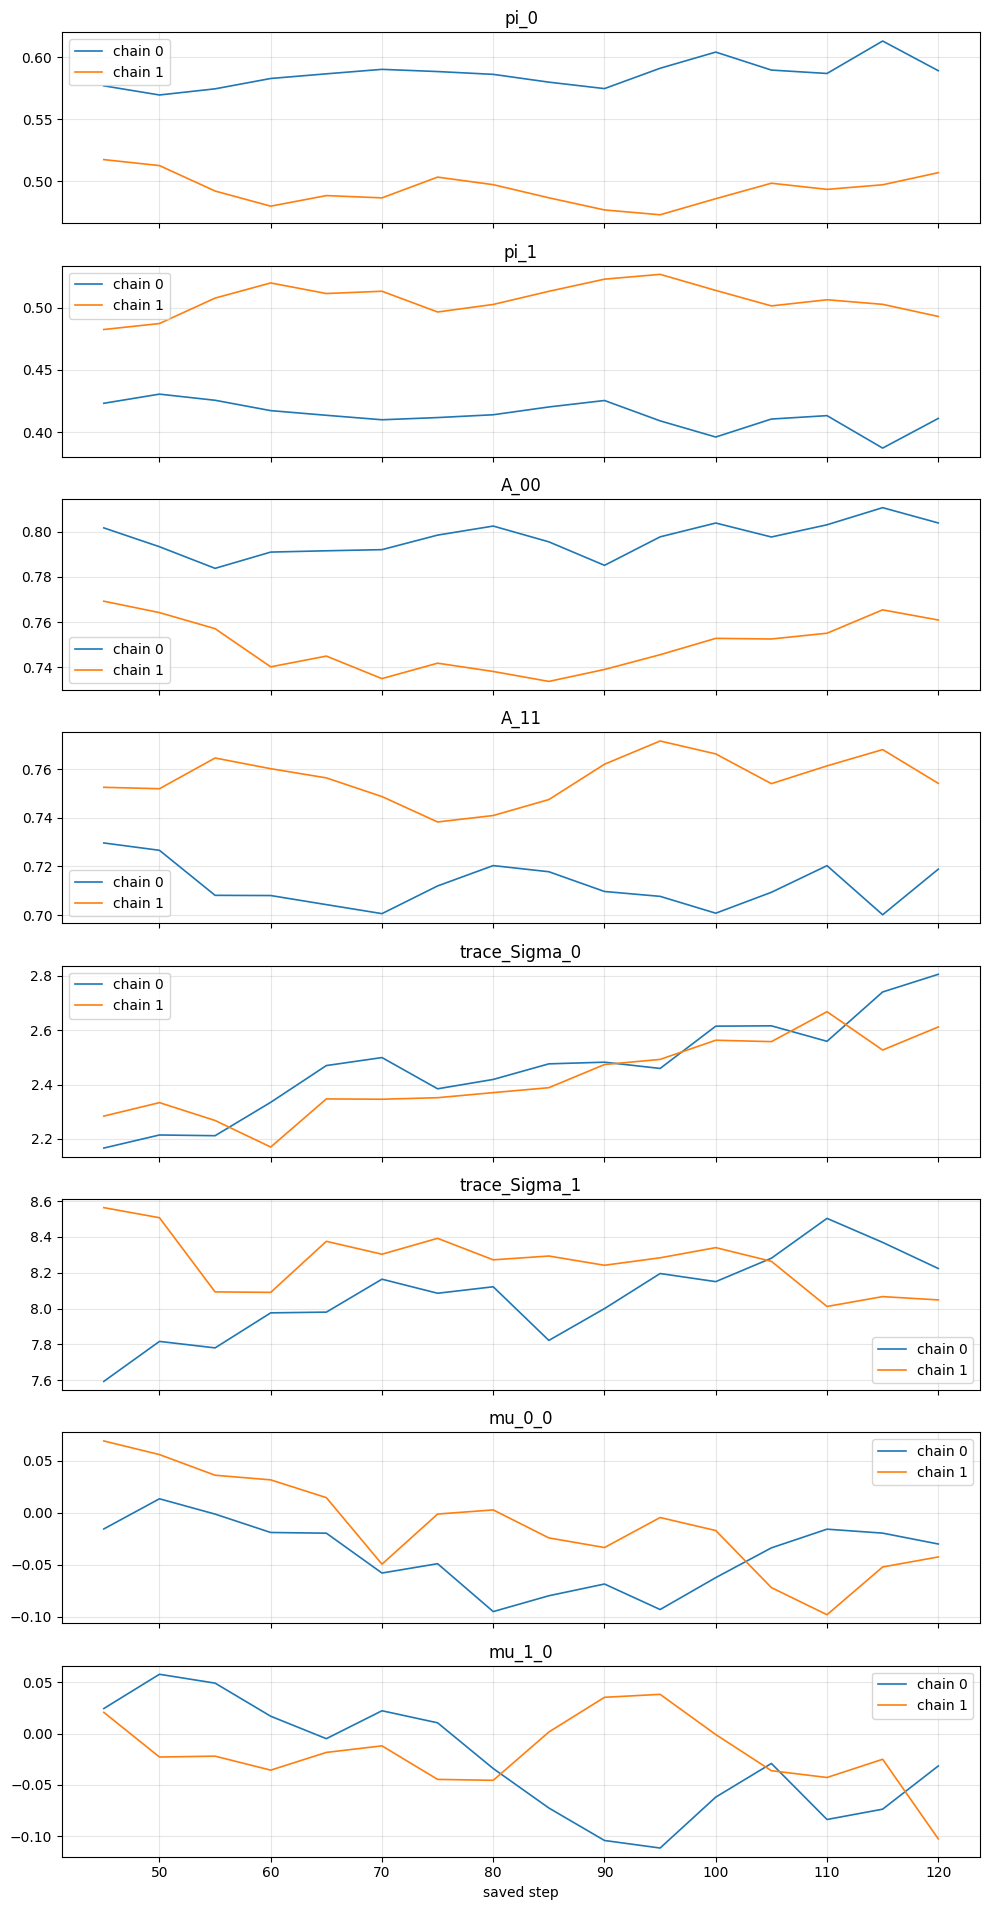

In [23]:
summary_rows = []
for var in MONITORED_VARS:
    values = np.concatenate([df[var].to_numpy() for df in chain_dfs])
    summary_rows.append({
        'variable': var,
        'mean': float(np.mean(values)),
        'sd': float(np.std(values, ddof=1)),
        'q05': float(np.quantile(values, 0.05)),
        'median': float(np.quantile(values, 0.50)),
        'q95': float(np.quantile(values, 0.95)),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

fig, axes = plt.subplots(len(MONITORED_VARS), 1, figsize=(10, 2.4 * len(MONITORED_VARS)), sharex=True)
if len(MONITORED_VARS) == 1:
    axes = [axes]
for ax, var in zip(axes, MONITORED_VARS):
    for chain_id, df in enumerate(chain_dfs):
        ax.plot(df['step'], df[var], lw=1.2, label=f'chain {chain_id}')
    ax.set_title(var)
    ax.grid(alpha=0.3)
    ax.legend()
axes[-1].set_xlabel('saved step')
plt.tight_layout()
plt.show()

## Smoothed regime occupancy from the posterior mean of the pilot chains

This is the main sanity check: if the preprocessing and simpler model help, the second state should get nontrivial occupancy rather than disappearing almost entirely.

posterior-mean most-likely state shares: [0.6003009 0.3996991]
posterior-mean average smoothed state probabilities: [0.5816605 0.4183517]


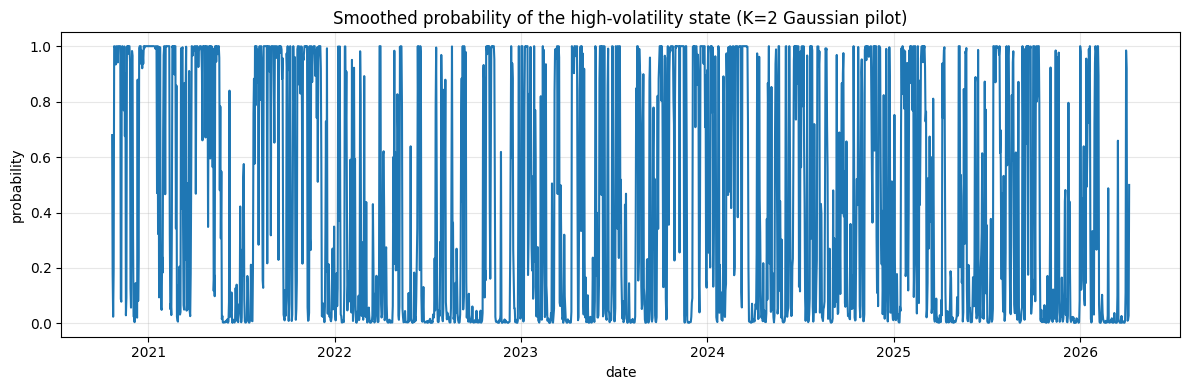

,state,ml_share,avg_smoothed_prob
0,state_0,0.600301,0.581661
1,state_1,0.399699,0.418352


In [33]:
flat_stack = np.vstack([out['flat_samples'] for out in chain_outputs if len(out['flat_samples']) > 0])
_, unravel_fn = ravel_pytree(params_map)
params_post_mean = unravel_fn(jnp.array(flat_stack.mean(axis=0)))

ll_pm, gamma_pm = smooth_states(params_post_mean, R)
gamma_pm_np = np.asarray(gamma_pm)
order = np.argsort(np.trace(np.asarray(unpack_params(params_post_mean)[4]), axis1=1, axis2=2))
gamma_pm_np = gamma_pm_np[:, order]
ml_state = gamma_pm_np.argmax(axis=1)
state_share = np.bincount(ml_state, minlength=K) / len(ml_state)

print('posterior-mean most-likely state shares:', state_share)
print('posterior-mean average smoothed state probabilities:', gamma_pm_np.mean(axis=0))

smoothed_df = pd.DataFrame({
    'date': dates,
    'state_0_prob': gamma_pm_np[:, 0],
    'state_1_prob': gamma_pm_np[:, 1],
    'ml_state': ml_state,
})
smoothed_df.to_pickle(OUT_DIR / 'smoothed_state_probs.pkl')

plt.figure(figsize=(12, 4))
plt.plot(pd.to_datetime(smoothed_df['date']), smoothed_df['state_1_prob'], lw=1.5)
plt.title('Smoothed probability of the high-volatility state (K=2 Gaussian pilot)')
plt.xlabel('date')
plt.ylabel('probability')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    'state': [f'state_{k}' for k in range(K)],
    'ml_share': state_share,
    'avg_smoothed_prob': gamma_pm_np.mean(axis=0),
}))

## How to read this pilot

If this notebook still puts essentially all mass on one state, then the issue is not just the original Student-t chains. If the occupancy becomes meaningfully more balanced, then the preprocessing and simpler Gaussian specification are probably helping.